In [1]:
# cell 1
import cv2
import mediapipe as mp
import os
import csv
import urllib.request
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Download the required model file automatically if it doesn't exist
model_path = 'hand_landmarker.task'
if not os.path.exists(model_path):
    print("Downloading Hand Landmarker model asset...")
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    urllib.request.urlretrieve(url, model_path)
    print("Download complete!")

# Initialize the modern Tasks API
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    running_mode=vision.RunningMode.IMAGE 
)
detector = vision.HandLandmarker.create_from_options(options)

DATA_DIR = r"C:\Users\dhars\OneDrive\Desktop\new lang"
CLASSES = ["african beer", "hello", "how", "how are you", "okay", "think"]
CSV_FILE = "hand_landmarks.csv"

# Configuration for Video Processing
VIDEO_EXTENSIONS = ('.mp4', '.avi', '.mov', '.mkv')
FRAME_STRIDE = 5 

print("Starting relative coordinate extraction from images and videos...")

def process_landmarks(results, class_name, csv_writer):
    """Helper function to normalize landmarks and write to CSV."""
    if not results.hand_landmarks:
        return False

    row_original = [class_name]
    row_inverted = [class_name]
    
    # SAFETY LOCK: Force a maximum of 2 hands
    hands_to_process = results.hand_landmarks[:2]
    
    for hand_landmarks in hands_to_process:
        wrist = hand_landmarks[0] 
        wrist_x, wrist_y, wrist_z = wrist.x, wrist.y, wrist.z
        
        for landmark in hand_landmarks:
            relative_x = landmark.x - wrist_x
            relative_y = landmark.y - wrist_y
            relative_z = landmark.z - wrist_z
            
            row_original.extend([relative_x, relative_y, relative_z])
            row_inverted.extend([relative_x * -1, relative_y, relative_z])
    
    # Zero-padding for single-hand detections
    if len(hands_to_process) == 1:
        row_original.extend([0] * 63)
        row_inverted.extend([0] * 63)
        
    # FINAL VERIFICATION: Only write to CSV if it perfectly matches 127 columns (1 label + 126 features)
    if len(row_original) == 127:
        csv_writer.writerow(row_original)
        csv_writer.writerow(row_inverted)
        return True
    else:
        return False

with open(CSV_FILE, mode='w', newline='') as f:
    csv_writer = csv.writer(f, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
    
    header = ['label']
    for i in range(42):
        header.extend([f'x{i}', f'y{i}', f'z{i}'])
    csv_writer.writerow(header)

    for class_name in CLASSES:
        folder_path = os.path.join(DATA_DIR, class_name)
        if not os.path.exists(folder_path):
            print(f"Warning: Directory not found -> {folder_path}")
            continue

        vectors_extracted = 0
        files_skipped = 0
        
        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            
            if file_name.lower().endswith(VIDEO_EXTENSIONS):
                cap = cv2.VideoCapture(file_path)
                frame_idx = 0
                
                while cap.isOpened():
                    ret, frame = cap.read()
                    if not ret:
                        break
                    
                    if frame_idx % FRAME_STRIDE == 0:
                        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                        # Modern API requires Image conversion
                        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
                        results = detector.detect(mp_image)
                        
                        if process_landmarks(results, class_name, csv_writer):
                            vectors_extracted += 2
                            
                    frame_idx += 1
                cap.release()
            
            else:
                image = cv2.imread(file_path)
                if image is None:
                    files_skipped += 1
                    continue

                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                # Modern API requires Image conversion
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
                results = detector.detect(mp_image)
                
                if process_landmarks(results, class_name, csv_writer):
                    vectors_extracted += 2
                else:
                    files_skipped += 1

        print(f"Class '{class_name}': Extracted {vectors_extracted} vectors. Skipped/Empty elements: {files_skipped}")

print(f"Data normalization complete. Output written to {CSV_FILE}")


Starting relative coordinate extraction from images and videos...
Class 'african beer': Extracted 42 vectors. Skipped/Empty elements: 0
Class 'hello': Extracted 48 vectors. Skipped/Empty elements: 0
Class 'how': Extracted 38 vectors. Skipped/Empty elements: 1
Class 'how are you': Extracted 16 vectors. Skipped/Empty elements: 0
Class 'okay': Extracted 22 vectors. Skipped/Empty elements: 0
Class 'think': Extracted 28 vectors. Skipped/Empty elements: 0
Data normalization complete. Output written to hand_landmarks.csv


Initializing data ingestion sequence...
Class mapping: {0: 'african beer', 1: 'hello', 2: 'how', 3: 'how are you', 4: 'okay', 5: 'think'}


Initiating training sequence...
Epoch 1/100


3/3 [==============================] - 2s 186ms/step - loss: 1.7907 - accuracy: 0.1742 - val_loss: 1.7738 - val_accuracy: 0.2308
Epoch 2/100
3/3 [==============================] - 0s 25ms/step - loss: 1.7708 - accuracy: 0.2452 - val_loss: 1.7534 - val_accuracy: 0.2564
Epoch 3/100
3/3 [==============================] - 0s 23ms/step - loss: 1.7518 - accuracy: 0.2710 - val_loss: 1.7331 - val_accuracy: 0.3077
Epoch 4/100
3/3 [==============================] - 0s 18ms/step - loss: 1.7321 - accuracy: 0.2645 - val_loss: 1.7096 - val_accuracy: 0.3590
Epoch 5/100
3/3 [==============================] - 0s 15ms/step - loss: 1.7172 - accuracy: 0.2774 - val_loss: 1.6839 - val_accuracy: 0.3590
Epoch 6/100
3/3 [==============================] - 0s 15ms/step - loss: 1.6835 - accuracy: 0.3226 - val_loss: 1.6547 - val_ac

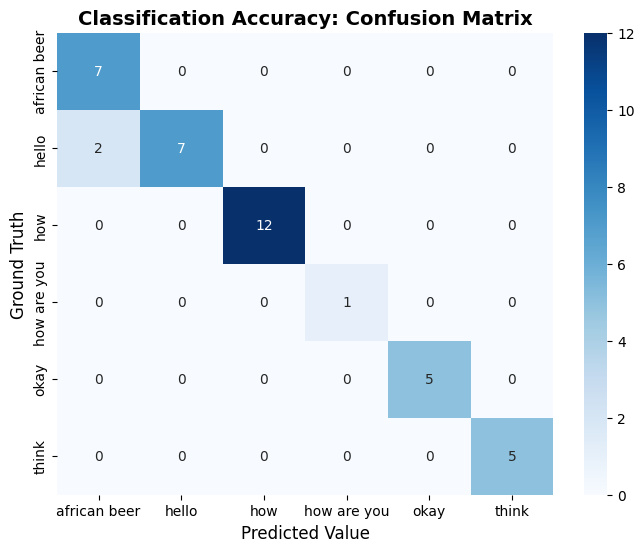

In [2]:
# cell 2
import pandas as pd
import numpy as np
import tensorflow as tf
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

CSV_FILE = "hand_landmarks.csv"
print("Initializing data ingestion sequence...")
df = pd.read_csv(CSV_FILE)

X = df.drop('label', axis=1).values
y_strings = df['label'].values

encoder = LabelEncoder()
y = encoder.fit_transform(y_strings)
class_names = encoder.classes_
print(f"Class mapping: {dict(enumerate(class_names))}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Adjusted dense network to accommodate expanded video/image hybrid data structures
model = Sequential([
    Input(shape=(126,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Initiating training sequence...")
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test))

# ABSOLUTE PATH FIX: Saves directly into your dataset folder
save_path = r"C:\Users\dhars\OneDrive\Desktop\new lang\landmark_model.keras"
model.save(save_path)
print(f"Training execution complete. Model serialized securely at: {save_path}")

print("Generating evaluation metrics...")
predictions = model.predict(X_test, verbose=0)
y_pred = np.argmax(predictions, axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Classification Accuracy: Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=12)
plt.xlabel('Predicted Value', fontsize=12)
plt.show()

In [1]:
# cell 3
import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf
import os
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.framework.formats import landmark_pb2

def start_smart_interpreter():
    # ABSOLUTE PATH FIX: Matches the exact location from Cell 2
    model_path = r"C:\Users\dhars\OneDrive\Desktop\new lang\landmark_model.keras"
    print(f"Loading serialized model from {model_path}...")
    
    try:
        model = tf.keras.models.load_model(model_path)
        print("Model loaded successfully!")
    except Exception as e:
        print(f"Model initialization failed: {e}")
        return

    class_names = ["african beer", "hello", "how", "how are you", "okay", "think"]
    print(f"Active interpretation classes: {class_names}")
    
    # Required specifically to access drawing connection maps
    mp_hands = mp.solutions.hands
    mp_drawing = mp.solutions.drawing_utils

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Hardware error: VideoCapture device inaccessible.")
        return

    print("Interpreter active. Select the rendering window and press 'q' to terminate.")

    # Initialize the modern Tasks API for live interpretation
    base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
    options = vision.HandLandmarkerOptions(
        base_options=base_options,
        num_hands=2,
        min_hand_detection_confidence=0.5,
        min_hand_presence_confidence=0.5,
        min_tracking_confidence=0.5,
        running_mode=vision.RunningMode.IMAGE 
    )
    
    with vision.HandLandmarker.create_from_options(options) as detector:
        
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.flip(frame, 1)
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
            
            # Detect landmarks using the modern API
            results = detector.detect(mp_image)

            if results.hand_landmarks:
                live_coordinates = []
                
                for hand_landmarks in results.hand_landmarks:
                    # Bridge conversion: Allows modern API data to use legacy drawing utils
                    hand_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
                    hand_landmarks_proto.landmark.extend([
                        landmark_pb2.NormalizedLandmark(x=landmark.x, y=landmark.y, z=landmark.z) for landmark in hand_landmarks
                    ])
                    mp_drawing.draw_landmarks(frame, hand_landmarks_proto, mp_hands.HAND_CONNECTIONS)
                    
                    wrist = hand_landmarks[0]
                    wrist_x, wrist_y, wrist_z = wrist.x, wrist.y, wrist.z
                    
                    for landmark in hand_landmarks:
                        live_coordinates.extend([
                            landmark.x - wrist_x, 
                            landmark.y - wrist_y, 
                            landmark.z - wrist_z
                        ])
                
                if len(results.hand_landmarks) == 1:
                    live_coordinates.extend([0] * 63)
                    
                if len(live_coordinates) == 126:
                    input_data = np.array([live_coordinates])
                    predictions = model.predict(input_data, verbose=0)
                    class_idx = np.argmax(predictions[0])
                    confidence = predictions[0][class_idx] * 100
                    
                    if confidence > 80: 
                        text = f"{class_names[class_idx]}: {confidence:.1f}%"
                        cv2.rectangle(frame, (10, 10), (450, 60), (0, 0, 0), -1) 
                        cv2.putText(frame, text, (20, 45), cv2.FONT_HERSHEY_SIMPLEX, 
                                    1, (0, 255, 0), 2, cv2.LINE_AA)

            cv2.imshow('Interpreter Diagnostics', frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

    cap.release()
    cv2.destroyAllWindows()

start_smart_interpreter()


Loading serialized model from C:\Users\dhars\OneDrive\Desktop\new lang\landmark_model.keras...


Model loaded successfully!
Active interpretation classes: ['african beer', 'hello', 'how', 'how are you', 'okay', 'think']
Interpreter active. Select the rendering window and press 'q' to terminate.
